In [1]:
from pathlib import Path
import sys
import pandas as pd 
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cwd = Path.cwd()

JOEL_DIR = cwd.parent

train_path = JOEL_DIR / 'dat_train1.csv'

print('JOEL_DIR:', JOEL_DIR)
print('Training data path: ', train_path)

JOEL_DIR: /Users/joelyoon/Documents/git_repo/m148-project/joel
Training data path:  /Users/joelyoon/Documents/git_repo/m148-project/joel/dat_train1.csv


In [3]:
df = pd.read_csv(train_path)

In [4]:
df.dtypes

customer_id                 int64
account_id                  int64
ed_id                       int64
event_name                 object
event_timestamp            object
journey_steps_until_end     int64
id                         object
sep                        object
dtype: object

In [5]:
df.head()

,customer_id,account_id,ed_id,event_name,event_timestamp,journey_steps_until_end,id,sep
0,15849251,383997507,4,browse_products,2021-11-04T14:11:15Z,1,15849251 383997507,-
1,15849251,383997507,4,browse_products,2021-11-04T14:11:29Z,2,15849251 383997507,-
2,15849251,383997507,4,browse_products,2021-11-04T14:12:10Z,3,15849251 383997507,-
3,15849251,383997507,4,browse_products,2021-11-04T14:12:21Z,4,15849251 383997507,-
4,15849251,383997507,4,browse_products,2021-11-04T14:12:24Z,5,15849251 383997507,-


In [6]:
successes = df.query('event_name == "order_shipped"')
successes.head()

,customer_id,account_id,ed_id,event_name,event_timestamp,journey_steps_until_end,id,sep
251,-1257367741,1076891306,28,order_shipped,2023-01-17T00:00:00Z,45,-1257367741 1076891306,-
455,1406169052,-405387821,28,order_shipped,2021-06-01T00:00:00Z,8,1406169052 -405387821,-
571,1621825105,1696883893,28,order_shipped,2022-06-17T00:00:00Z,76,1621825105 1696883893,-
597,1896716214,-1415717586,28,order_shipped,2021-12-23T00:00:00Z,10,1896716214 -1415717586,-
830,940754364,-2103448386,28,order_shipped,2022-01-28T00:00:00Z,198,940754364 -2103448386,-


In [7]:
successes['event_timestamp'] = pd.to_datetime(successes['event_timestamp'])

/var/folders/t0/cl4mx7656030fy5dm2t2jwsr0000gn/T/ipykernel_17823/2203270280.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successes['event_timestamp'] = pd.to_datetime(successes['event_timestamp'])


In [8]:
successes.dtypes

customer_id                              int64
account_id                               int64
ed_id                                    int64
event_name                              object
event_timestamp            datetime64[ns, UTC]
journey_steps_until_end                  int64
id                                      object
sep                                     object
dtype: object

In [9]:
successes.head()

,customer_id,account_id,ed_id,event_name,event_timestamp,journey_steps_until_end,id,sep
251,-1257367741,1076891306,28,order_shipped,2023-01-17 00:00:00+00:00,45,-1257367741 1076891306,-
455,1406169052,-405387821,28,order_shipped,2021-06-01 00:00:00+00:00,8,1406169052 -405387821,-
571,1621825105,1696883893,28,order_shipped,2022-06-17 00:00:00+00:00,76,1621825105 1696883893,-
597,1896716214,-1415717586,28,order_shipped,2021-12-23 00:00:00+00:00,10,1896716214 -1415717586,-
830,940754364,-2103448386,28,order_shipped,2022-01-28 00:00:00+00:00,198,940754364 -2103448386,-


In [10]:
successes['date'] = successes['event_timestamp'].dt.date

/var/folders/t0/cl4mx7656030fy5dm2t2jwsr0000gn/T/ipykernel_17823/120311157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successes['date'] = successes['event_timestamp'].dt.date


In [11]:
number_of_successes = pd.DataFrame(successes.groupby('date').size()).reset_index()
number_of_successes.columns = ['ds', 'y']

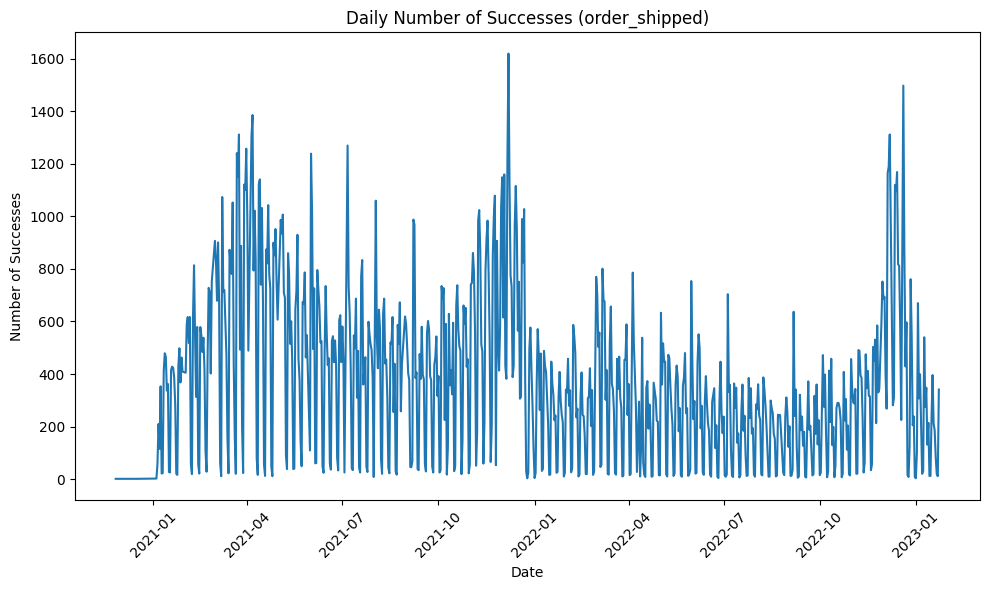

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='ds', y='y', data=number_of_successes)
plt.xlabel('Date')
plt.ylabel('Number of Successes')
plt.title('Daily Number of Successes (order_shipped)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
m = Prophet()
m.fit(number_of_successes)


13:52:45 - cmdstanpy - INFO - Chain [1] start processing
13:52:45 - cmdstanpy - INFO - Chain [1] done processing


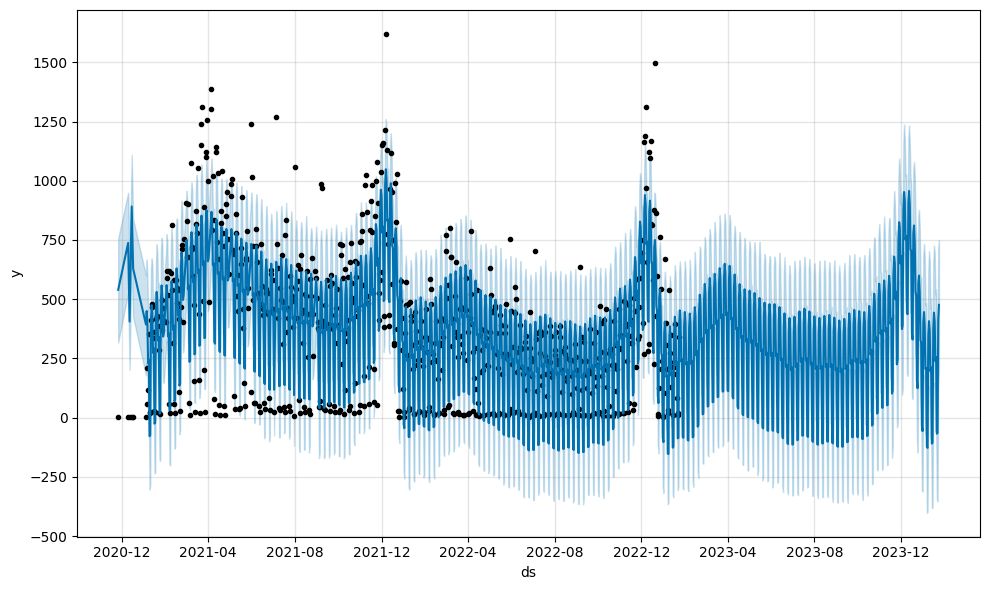

In [14]:
future = m.make_future_dataframe(periods=365)
future.tail()

forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

fig1 = m.plot(forecast)


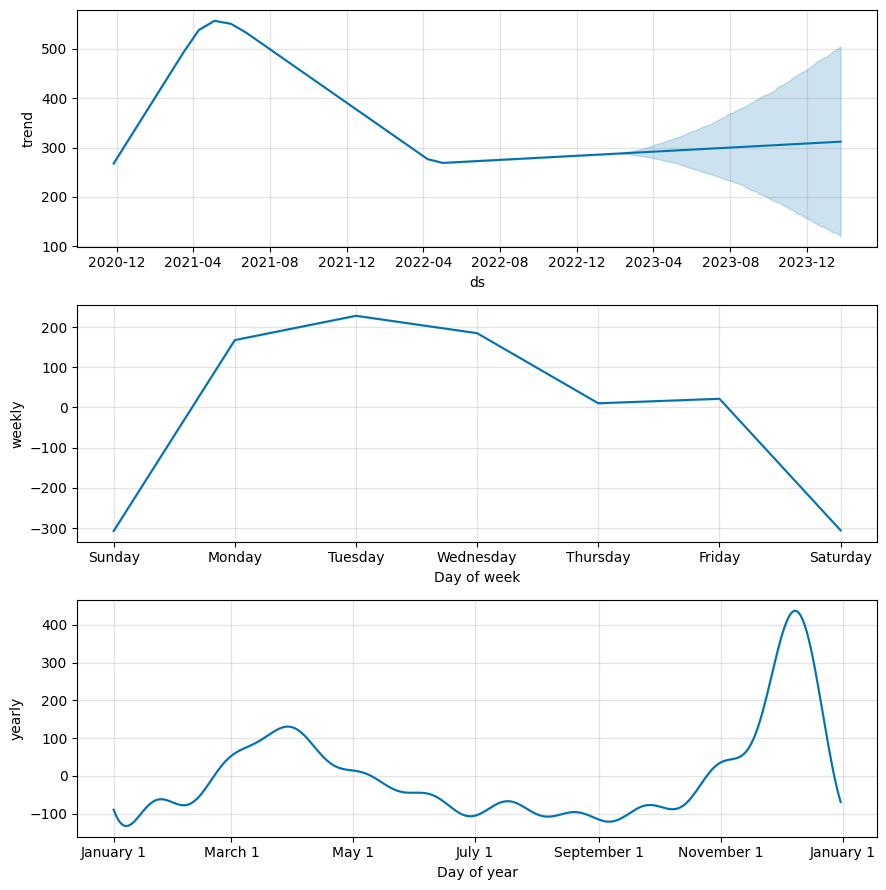

In [15]:
fig2 = m.plot_components(forecast)


In [16]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)
plot_components_plotly(m, forecast)
